In [1]:
# ============================================================
# 污水处理厂出水水质预测项目
# Notebook 01: Data Understanding
#
# 目的：
# 1. 读取 COD、TN、TP 三个数据集
# 2. 了解数据集的基本结构、时间范围和采样频率
# 3. 检查缺失值、重复值和时间序列缺口
# 4. 比较三个数据集的共同特征是否一致
# 5. 理解 COD、TN、TP 三个预测目标的基本分布
#
# 本 Notebook 只进行数据理解和数据质量检查，
# 暂时不进行特征工程、数据标准化或模型训练。
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Libraries imported successfully.")

C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Administrator\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Libraries imported successfully.


In [2]:
# ============================================================
# 1. 读取数据
#
# 三个数据集共享相同的污水处理过程变量，
# 主要区别是最后一列 eff：
#
# COD 数据集：eff = 出水 COD
# TN 数据集： eff = 出水 TN
# TP 数据集： eff = 出水 TP
# ============================================================

from pathlib import Path

# Notebook 位于 notebooks/ 文件夹，因此数据位于上一级目录的 data/
DATA_DIR = Path("../data")

cod = pd.read_csv(DATA_DIR / "cod.csv")
tn = pd.read_csv(DATA_DIR / "tn.csv")
tp = pd.read_csv(DATA_DIR / "tp.csv")

datasets = {
    "COD": cod,
    "TN": tn,
    "TP": tp
}

print("数据读取完成。")

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

数据读取完成。
COD: 6,289 rows × 24 columns
TN: 6,289 rows × 24 columns
TP: 6,289 rows × 24 columns


In [3]:
# ============================================================
# 2. 查看数据基本结构
#
# 观察：
# - 每一行代表什么
# - 有哪些 columns
# - 数据类型是什么
# - eff 在不同数据集中是什么样
# ============================================================

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(f"{name} DATASET")
    print("=" * 70)

    display(df.head())

    print("\n数据类型：")
    print(df.dtypes)


COD DATASET


,sampling_time,Q1,Q2,TCOD,TKN,TP,SNHx,Airflow1_1,Airflow1_2,Airflow2_1,Airflow2_2,PAC1,PAC2,PAC_HE,Reflux1_1,Reflux1_2,Reflux2_1,Reflux2_2,RAS1,RAS2,WAS1,WAS2,T,eff
0,2022/7/7 1:00,213876.0469,215916.3281,100.857208,17.493128,1.874819,12.778863,100920.13920,99513.88625,105381.9478,105868.0532,19.399306,19.282987,0.005199,151357.0210,147804.9616,145766.3191,144295.3142,156761.6250,135849.4805,2078.041626,3.312500,26.66,6.800611
1,2022/7/7 3:00,207205.8984,208029.8672,105.016640,16.621456,1.650752,12.305773,100243.05470,99583.33742,106597.2246,106718.7510,19.552084,19.315972,0.005978,151093.7093,147882.9410,145578.0676,144396.9605,157437.5039,135451.9102,2089.083252,0.000000,26.67,6.785675
2,2022/7/7 5:00,197750.0156,194944.6289,192.672165,24.542463,2.484990,15.972222,100017.36040,98072.91796,106197.9141,106579.8589,19.350694,19.151042,0.005133,151539.3128,148075.6930,146044.2587,144609.5040,158033.8594,133026.7383,2078.041626,5.520833,26.68,6.794892
3,2022/7/7 7:00,213346.3594,209618.9297,96.752022,17.473234,1.637912,13.666450,99392.35693,97673.61036,106111.1133,107256.9448,19.428819,19.225694,0.005184,151640.5985,148426.7753,145796.8216,144753.6665,156562.8516,134219.4492,2106.750000,3.312500,26.69,6.902074
4,2022/7/7 9:00,213483.6797,212600.8594,191.225403,20.777271,2.304688,12.914496,54097.22168,45434.02843,106475.6924,105000.0015,19.539931,19.350695,0.005154,151296.2524,148083.9780,146149.8928,144908.8044,158232.6446,133901.3906,2084.666748,2.208333,26.70,7.193573



数据类型：
sampling_time        str
Q1               float64
Q2               float64
TCOD             float64
TKN              float64
TP               float64
SNHx             float64
Airflow1_1       float64
Airflow1_2       float64
Airflow2_1       float64
Airflow2_2       float64
PAC1             float64
PAC2             float64
PAC_HE           float64
Reflux1_1        float64
Reflux1_2        float64
Reflux2_1        float64
Reflux2_2        float64
RAS1             float64
RAS2             float64
WAS1             float64
WAS2             float64
T                float64
eff              float64
dtype: object

TN DATASET


,sampling_time,Q1,Q2,TCOD,TKN,TP,SNHx,Airflow1_1,Airflow1_2,Airflow2_1,Airflow2_2,PAC1,PAC2,PAC_HE,Reflux1_1,Reflux1_2,Reflux2_1,Reflux2_2,RAS1,RAS2,WAS1,WAS2,T,eff
0,2022/7/7 1:00,213876.0469,215916.3281,100.857208,17.493128,1.874819,12.778863,100920.13920,99513.88625,105381.9478,105868.0532,19.399306,19.282987,0.005199,151357.0210,147804.9616,145766.3191,144295.3142,156761.6250,135849.4805,2078.041626,3.312500,26.66,7.215980
1,2022/7/7 3:00,207205.8984,208029.8672,105.016640,16.621456,1.650752,12.305773,100243.05470,99583.33742,106597.2246,106718.7510,19.552084,19.315972,0.005978,151093.7093,147882.9410,145578.0676,144396.9605,157437.5039,135451.9102,2089.083252,0.000000,26.67,7.385564
2,2022/7/7 5:00,197750.0156,194944.6289,192.672165,24.542463,2.484990,15.972222,100017.36040,98072.91796,106197.9141,106579.8589,19.350694,19.151042,0.005133,151539.3128,148075.6930,146044.2587,144609.5040,158033.8594,133026.7383,2078.041626,5.520833,26.68,7.678251
3,2022/7/7 7:00,213346.3594,209618.9297,96.752022,17.473234,1.637912,13.666450,99392.35693,97673.61036,106111.1133,107256.9448,19.428819,19.225694,0.005184,151640.5985,148426.7753,145796.8216,144753.6665,156562.8516,134219.4492,2106.750000,3.312500,26.69,7.845944
4,2022/7/7 9:00,213483.6797,212600.8594,191.225403,20.777271,2.304688,12.914496,54097.22168,45434.02843,106475.6924,105000.0015,19.539931,19.350695,0.005154,151296.2524,148083.9780,146149.8928,144908.8044,158232.6446,133901.3906,2084.666748,2.208333,26.70,7.920221



数据类型：
sampling_time        str
Q1               float64
Q2               float64
TCOD             float64
TKN              float64
TP               float64
SNHx             float64
Airflow1_1       float64
Airflow1_2       float64
Airflow2_1       float64
Airflow2_2       float64
PAC1             float64
PAC2             float64
PAC_HE           float64
Reflux1_1        float64
Reflux1_2        float64
Reflux2_1        float64
Reflux2_2        float64
RAS1             float64
RAS2             float64
WAS1             float64
WAS2             float64
T                float64
eff              float64
dtype: object

TP DATASET


,sampling_time,Q1,Q2,TCOD,TKN,TP,SNHx,Airflow1_1,Airflow1_2,Airflow2_1,Airflow2_2,PAC1,PAC2,PAC_HE,Reflux1_1,Reflux1_2,Reflux2_1,Reflux2_2,RAS1,RAS2,WAS1,WAS2,T,eff
0,2022/7/7 1:00,213876.0469,215916.3281,100.857208,17.493128,1.874819,12.778863,100920.13920,99513.88625,105381.9478,105868.0532,19.399306,19.282987,0.005199,151357.0210,147804.9616,145766.3191,144295.3142,156761.6250,135849.4805,2078.041626,3.312500,26.66,0.168367
1,2022/7/7 3:00,207205.8984,208029.8672,105.016640,16.621456,1.650752,12.305773,100243.05470,99583.33742,106597.2246,106718.7510,19.552084,19.315972,0.005978,151093.7093,147882.9410,145578.0676,144396.9605,157437.5039,135451.9102,2089.083252,0.000000,26.67,0.180514
2,2022/7/7 5:00,197750.0156,194944.6289,192.672165,24.542463,2.484990,15.972222,100017.36040,98072.91796,106197.9141,106579.8589,19.350694,19.151042,0.005133,151539.3128,148075.6930,146044.2587,144609.5040,158033.8594,133026.7383,2078.041626,5.520833,26.68,0.192639
3,2022/7/7 7:00,213346.3594,209618.9297,96.752022,17.473234,1.637912,13.666450,99392.35693,97673.61036,106111.1133,107256.9448,19.428819,19.225694,0.005184,151640.5985,148426.7753,145796.8216,144753.6665,156562.8516,134219.4492,2106.750000,3.312500,26.69,0.209947
4,2022/7/7 9:00,213483.6797,212600.8594,191.225403,20.777271,2.304688,12.914496,54097.22168,45434.02843,106475.6924,105000.0015,19.539931,19.350695,0.005154,151296.2524,148083.9780,146149.8928,144908.8044,158232.6446,133901.3906,2084.666748,2.208333,26.70,0.231021



数据类型：
sampling_time        str
Q1               float64
Q2               float64
TCOD             float64
TKN              float64
TP               float64
SNHx             float64
Airflow1_1       float64
Airflow1_2       float64
Airflow2_1       float64
Airflow2_2       float64
PAC1             float64
PAC2             float64
PAC_HE           float64
Reflux1_1        float64
Reflux1_2        float64
Reflux2_1        float64
Reflux2_2        float64
RAS1             float64
RAS2             float64
WAS1             float64
WAS2             float64
T                float64
eff              float64
dtype: object


In [4]:
# ============================================================
# 3. 检查三个数据集的 Column Structure
#
# 目的：
# 确认 COD、TN、TP 是否具有相同的 column names。
# ============================================================

for name, df in datasets.items():
    print(f"\n{name} columns:")
    print(df.columns.tolist())

same_columns = (
    cod.columns.tolist() == tn.columns.tolist()
    and cod.columns.tolist() == tp.columns.tolist()
)

print("\n三个数据集的 column names 是否完全相同：", same_columns)


COD columns:
['sampling_time', 'Q1', 'Q2', 'TCOD', 'TKN', 'TP', 'SNHx', 'Airflow1_1', 'Airflow1_2', 'Airflow2_1', 'Airflow2_2', 'PAC1', 'PAC2', 'PAC_HE', 'Reflux1_1', 'Reflux1_2', 'Reflux2_1', 'Reflux2_2', 'RAS1', 'RAS2', 'WAS1', 'WAS2', 'T', 'eff']

TN columns:
['sampling_time', 'Q1', 'Q2', 'TCOD', 'TKN', 'TP', 'SNHx', 'Airflow1_1', 'Airflow1_2', 'Airflow2_1', 'Airflow2_2', 'PAC1', 'PAC2', 'PAC_HE', 'Reflux1_1', 'Reflux1_2', 'Reflux2_1', 'Reflux2_2', 'RAS1', 'RAS2', 'WAS1', 'WAS2', 'T', 'eff']

TP columns:
['sampling_time', 'Q1', 'Q2', 'TCOD', 'TKN', 'TP', 'SNHx', 'Airflow1_1', 'Airflow1_2', 'Airflow2_1', 'Airflow2_2', 'PAC1', 'PAC2', 'PAC_HE', 'Reflux1_1', 'Reflux1_2', 'Reflux2_1', 'Reflux2_2', 'RAS1', 'RAS2', 'WAS1', 'WAS2', 'T', 'eff']

三个数据集的 column names 是否完全相同： True


In [5]:
# ============================================================
# 4. 处理时间变量
#
# sampling_time 当前可能是字符串格式。
# 将其转换为 datetime，方便后续：
# - 检查时间范围
# - 检查采样间隔
# - 检查 missing timestamps
# ============================================================

for name, df in datasets.items():
    df["sampling_time"] = pd.to_datetime(df["sampling_time"])

print("sampling_time 已转换为 datetime。")

print("\nCOD sampling_time 示例：")
print(cod["sampling_time"].head())

sampling_time 已转换为 datetime。

COD sampling_time 示例：
0   2022-07-07 01:00:00
1   2022-07-07 03:00:00
2   2022-07-07 05:00:00
3   2022-07-07 07:00:00
4   2022-07-07 09:00:00
Name: sampling_time, dtype: datetime64[us]


In [6]:
# ============================================================
# 5. 检查时间序列结构
#
# 检查：
# - 起始时间
# - 结束时间
# - observation 数量
# - 相邻 observation 的时间间隔
# ============================================================

for name, df in datasets.items():

    time_diff = df["sampling_time"].sort_values().diff().dropna()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Start time:", df["sampling_time"].min())
    print("End time:  ", df["sampling_time"].max())
    print("Observations:", len(df))

    print("\n最常见的 sampling intervals:")
    print(time_diff.value_counts().head())


COD
Start time: 2022-07-07 01:00:00
End time:   2023-12-13 01:00:00
Observations: 6289

最常见的 sampling intervals:
sampling_time
0 days 02:00:00    6288
Name: count, dtype: int64

TN
Start time: 2022-07-07 01:00:00
End time:   2023-12-13 01:00:00
Observations: 6289

最常见的 sampling intervals:
sampling_time
0 days 02:00:00    6288
Name: count, dtype: int64

TP
Start time: 2022-07-07 01:00:00
End time:   2023-12-13 01:00:00
Observations: 6289

最常见的 sampling intervals:
sampling_time
0 days 02:00:00    6288
Name: count, dtype: int64


In [7]:
# ============================================================
# 6. Missing Value Check
#
# 检查每个 column 是否存在缺失值。
# ============================================================

for name, df in datasets.items():

    missing = df.isna().sum()
    total_missing = missing.sum()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(f"Total missing values: {total_missing}")

    if total_missing == 0:
        print("No missing values found.")
    else:
        print("\nColumns with missing values:")
        print(missing[missing > 0])


COD
Total missing values: 0
No missing values found.

TN
Total missing values: 0
No missing values found.

TP
Total missing values: 0
No missing values found.


In [8]:
# ============================================================
# 7. Duplicate Check
#
# 分别检查：
# 1. 完全重复的 rows
# 2. 重复的 sampling_time
# ============================================================

for name, df in datasets.items():

    duplicate_rows = df.duplicated().sum()
    duplicate_times = df["sampling_time"].duplicated().sum()

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Duplicate rows:", duplicate_rows)
    print("Duplicate timestamps:", duplicate_times)


COD
Duplicate rows: 0
Duplicate timestamps: 0

TN
Duplicate rows: 0
Duplicate timestamps: 0

TP
Duplicate rows: 0
Duplicate timestamps: 0


In [9]:
# ============================================================
# 8. Missing Timestamp Check
#
# 数据理论上每 2 小时记录一次。
# 因此构造完整的 2-hour 时间序列，
# 检查实际数据中是否缺少某些时间点。
# ============================================================

for name, df in datasets.items():

    expected_times = pd.date_range(
        start=df["sampling_time"].min(),
        end=df["sampling_time"].max(),
        freq="2h"
    )

    actual_times = pd.DatetimeIndex(df["sampling_time"])

    missing_times = expected_times.difference(actual_times)

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Expected timestamps:", len(expected_times))
    print("Actual timestamps:  ", len(actual_times))
    print("Missing timestamps: ", len(missing_times))

    if len(missing_times) > 0:
        print("\nFirst missing timestamps:")
        print(missing_times[:10])


COD
Expected timestamps: 6289
Actual timestamps:   6289
Missing timestamps:  0

TN
Expected timestamps: 6289
Actual timestamps:   6289
Missing timestamps:  0

TP
Expected timestamps: 6289
Actual timestamps:   6289
Missing timestamps:  0


In [10]:
# ============================================================
# 9. 比较 COD、TN、TP 三个数据集
#
# 三个数据集理论上：
# - sampling_time 相同
# - 所有 process features 相同
# - 只有 eff 不同
#
# 这里直接通过代码验证。
# ============================================================

common_columns = [
    col for col in cod.columns
    if col != "eff"
]

cod_tn_same = cod[common_columns].equals(tn[common_columns])
cod_tp_same = cod[common_columns].equals(tp[common_columns])
tn_tp_same = tn[common_columns].equals(tp[common_columns])

print("COD vs TN common features identical:", cod_tn_same)
print("COD vs TP common features identical:", cod_tp_same)
print("TN  vs TP common features identical:", tn_tp_same)

COD vs TN common features identical: True
COD vs TP common features identical: True
TN  vs TP common features identical: True


In [11]:
# ============================================================
# 10. 查看模型中的 Process Features
#
# sampling_time 不作为数值输入。
# eff 是对应污染指标的历史出水值和预测目标。
#
# 因此这里单独列出其余 process features。
# ============================================================

process_features = [
    col for col in cod.columns
    if col not in ["sampling_time", "eff"]
]

print(f"Number of process features: {len(process_features)}")

for i, feature in enumerate(process_features, start=1):
    print(f"{i:2d}. {feature}")

Number of process features: 22
 1. Q1
 2. Q2
 3. TCOD
 4. TKN
 5. TP
 6. SNHx
 7. Airflow1_1
 8. Airflow1_2
 9. Airflow2_1
10. Airflow2_2
11. PAC1
12. PAC2
13. PAC_HE
14. Reflux1_1
15. Reflux1_2
16. Reflux2_1
17. Reflux2_2
18. RAS1
19. RAS2
20. WAS1
21. WAS2
22. T


In [12]:
# ============================================================
# 11. Descriptive Statistics
#
# 查看每个 process variable 的：
# - mean
# - standard deviation
# - min
# - quartiles
# - max
#
# 主要用于理解不同变量的数值范围。
# ============================================================

summary = cod[process_features].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
Q1,6289.0,203988.133775,29822.048950,48260.400000,183664.320000,200025.600000,220350.000000,380904.000000
Q2,6289.0,196778.495571,29527.483351,0.000000,177445.312500,192786.621100,212738.160000,333643.200000
TCOD,6289.0,120.914981,38.271000,32.570168,91.724541,115.198204,145.887588,253.110535
TKN,6289.0,20.956917,3.635529,8.089193,18.601700,21.124495,23.327185,33.403862
TP,6289.0,1.457635,0.395988,0.331308,1.165180,1.414570,1.720920,3.085033
SNHx,6289.0,14.230797,3.029298,0.225694,12.178820,14.454200,16.309700,26.207682
Airflow1_1,6289.0,110235.308158,25345.317392,21024.312000,97760.415510,106510.412100,113767.248000,284340.272500
Airflow1_2,6289.0,110775.380919,28350.497102,28159.723390,97083.332510,106197.914100,113923.536000,301927.089900
Airflow2_1,6289.0,111860.245634,26932.619694,17690.973270,98177.087390,106093.560000,115520.832000,262048.608400
Airflow2_2,6289.0,110700.104497,24856.565283,17378.472290,98819.592000,106840.278800,114374.928000,354774.298800


In [13]:
# ============================================================
# 12. Target Summary
#
# 分别查看：
# - Effluent COD
# - Effluent TN
# - Effluent TP
#
# 的基本统计信息。
# ============================================================

target_summary = pd.DataFrame({
    "COD": cod["eff"].describe(),
    "TN": tn["eff"].describe(),
    "TP": tp["eff"].describe()
})

target_summary

,COD,TN,TP
count,6289.000000,6289.000000,6289.000000
mean,9.738127,8.563547,0.530925
std,1.983320,2.150683,0.325363
min,5.192459,3.430930,0.071559
25%,8.186388,6.977484,0.287849
50%,9.687473,8.630224,0.435349
75%,11.240023,10.142277,0.718744
max,15.950963,14.457026,2.473674


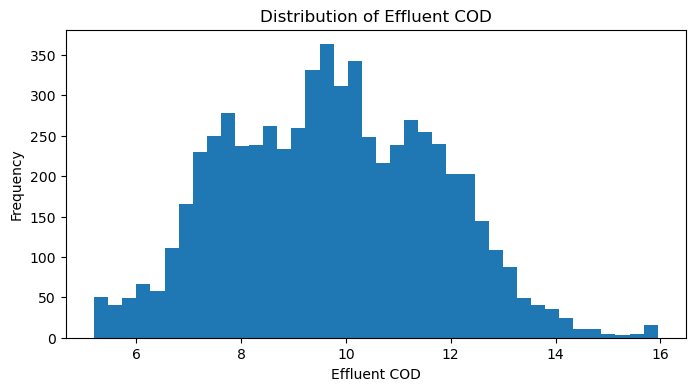

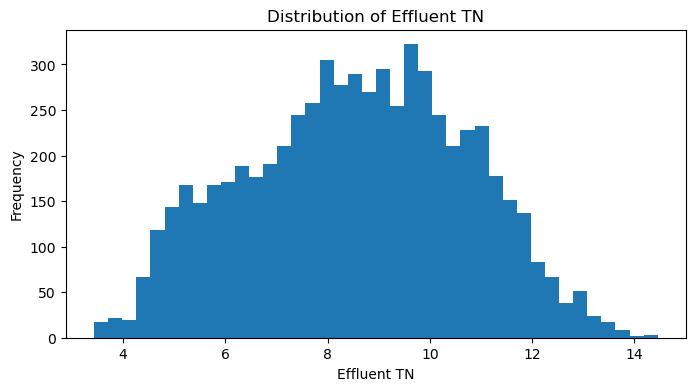

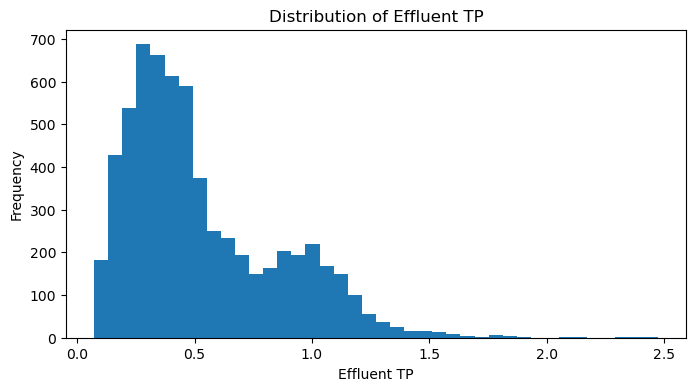

In [14]:
# ============================================================
# 13. Target Distribution
#
# 观察 COD、TN、TP 出水指标的整体分布。
# ============================================================

for name, df in datasets.items():

    plt.figure(figsize=(8, 4))

    plt.hist(df["eff"], bins=40)

    plt.title(f"Distribution of Effluent {name}")
    plt.xlabel(f"Effluent {name}")
    plt.ylabel("Frequency")

    plt.show()

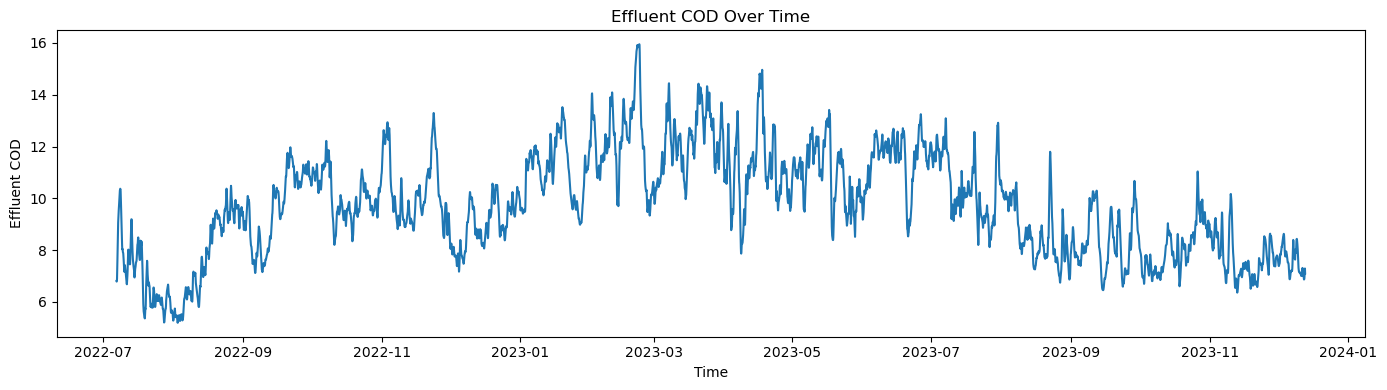

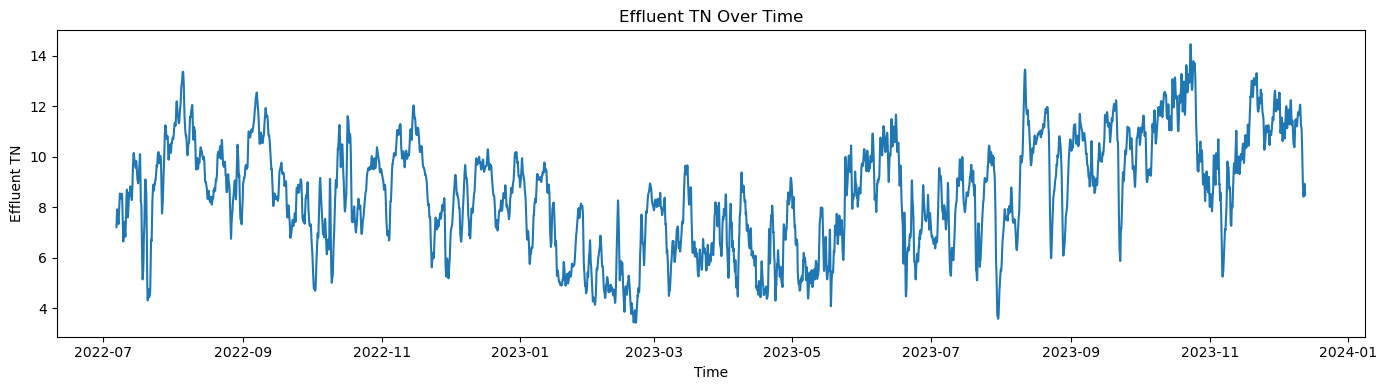

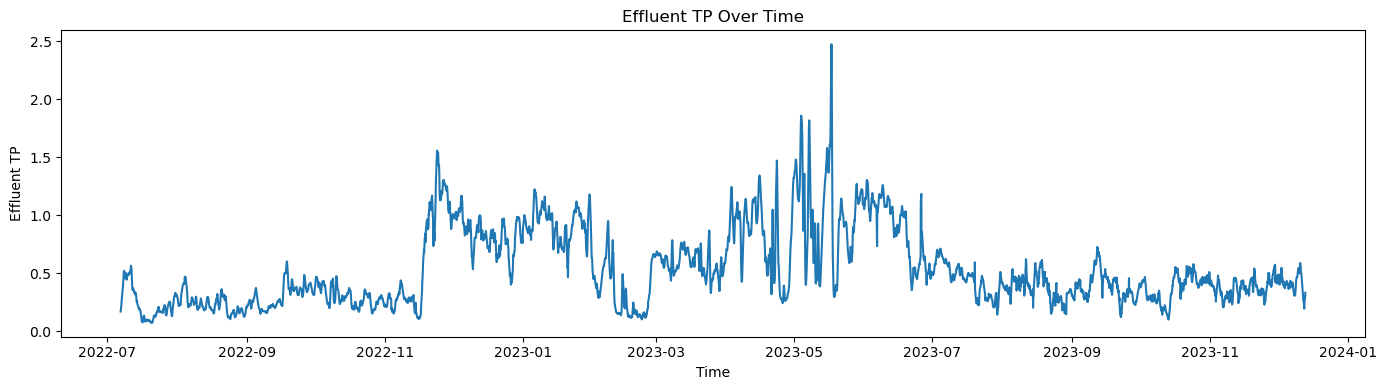

In [15]:
# ============================================================
# 14. Target Time Series
#
# 查看一年多时间内 COD、TN、TP 的变化情况。
#
# 这一步非常重要，因为后面我们需要判断：
# target 是否具有明显的 temporal continuity。
# ============================================================

for name, df in datasets.items():

    plt.figure(figsize=(14, 4))

    plt.plot(
        df["sampling_time"],
        df["eff"]
    )

    plt.title(f"Effluent {name} Over Time")
    plt.xlabel("Time")
    plt.ylabel(f"Effluent {name}")

    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# 15. Target Autocorrelation
#
# 检查当前 eff 与前一个时间点 eff 的相关程度。
#
# 由于采样间隔为 2 小时：
# lag 1 = 2 小时前
# lag 2 = 4 小时前
# lag 3 = 6 小时前
#
# 如果 lag-1 correlation 非常高，
# 说明水质具有很强的短期时间连续性。
# ============================================================

for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for lag in [1, 2, 3, 6, 12]:

        corr = df["eff"].corr(
            df["eff"].shift(lag)
        )

        print(
            f"Lag {lag:2d} "
            f"({lag * 2:2d} hours): "
            f"{corr:.4f}"
        )


COD
Lag  1 ( 2 hours): 0.9977
Lag  2 ( 4 hours): 0.9915
Lag  3 ( 6 hours): 0.9829
Lag  6 (12 hours): 0.9520
Lag 12 (24 hours): 0.8934

TN
Lag  1 ( 2 hours): 0.9969
Lag  2 ( 4 hours): 0.9886
Lag  3 ( 6 hours): 0.9771
Lag  6 (12 hours): 0.9364
Lag 12 (24 hours): 0.8595

TP
Lag  1 ( 2 hours): 0.9957
Lag  2 ( 4 hours): 0.9863
Lag  3 ( 6 hours): 0.9734
Lag  6 (12 hours): 0.9269
Lag 12 (24 hours): 0.8509


In [17]:
# ============================================================
# 16. Data Quality Summary
#
# 将三个数据集最重要的数据质量信息整理到一张表中，
# 方便后续写 README、报告和面试总结。
# ============================================================

summary_rows = []

for name, df in datasets.items():

    expected_times = pd.date_range(
        start=df["sampling_time"].min(),
        end=df["sampling_time"].max(),
        freq="2h"
    )

    missing_times = expected_times.difference(
        pd.DatetimeIndex(df["sampling_time"])
    )

    summary_rows.append({
        "Target": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Start": df["sampling_time"].min(),
        "End": df["sampling_time"].max(),
        "Missing Values": df.isna().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Duplicate Timestamps": df["sampling_time"].duplicated().sum(),
        "Missing Timestamps": len(missing_times),
        "Target Mean": df["eff"].mean(),
        "Target Min": df["eff"].min(),
        "Target Max": df["eff"].max()
    })

data_quality_summary = pd.DataFrame(summary_rows)

data_quality_summary

,Target,Rows,Columns,Start,End,Missing Values,Duplicate Rows,Duplicate Timestamps,Missing Timestamps,Target Mean,Target Min,Target Max
0,COD,6289,24,2022-07-07 01:00:00,2023-12-13 01:00:00,0,0,0,0,9.738127,5.192459,15.950963
1,TN,6289,24,2022-07-07 01:00:00,2023-12-13 01:00:00,0,0,0,0,8.563547,3.430930,14.457026
2,TP,6289,24,2022-07-07 01:00:00,2023-12-13 01:00:00,0,0,0,0,0.530925,0.071559,2.473674
